# Step 0 — Data Exploration: Zachary's Karate Club

This notebook loads the Karate Club dataset, inspects its structure, and visualizes the graph.
The goal is to build intuition about the data before moving on to spectral embeddings and autoencoders.

**Contents:**
1. Load and inspect the PyTorch Geometric dataset
2. Build and visualize the adjacency matrix
3. Compute degree distribution and graph statistics
4. Visualize the graph with community labels
5. Inspect the Laplacian and its spectrum

In [1]:
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_dense_adj, to_networkx

dataset = KarateClub()
data = dataset[0]

print("Dataset:", dataset)
print(f"Nodes:       {data.num_nodes}")
print(f"Edges:       {data.num_edges} (directed COO) → {data.num_edges // 2} undirected")
print(f"Features:    {data.num_node_features}")
print(f"Labels:      {data.y.unique().tolist()}")
print(f"\ndata.x shape:          {data.x.shape}")
print(f"data.edge_index shape: {data.edge_index.shape}")
print(f"data.y shape:          {data.y.shape}")

Dataset: KarateClub()
Nodes:       34
Edges:       156 (directed COO) → 78 undirected
Features:    34
Labels:      [0, 1, 2, 3]

data.x shape:          torch.Size([34, 34])
data.edge_index shape: torch.Size([2, 156])
data.y shape:          torch.Size([34])


## 2. Adjacency Matrix

Convert from COO edge_index to dense adjacency matrix and visualize.

Adjacency matrix shape: (34, 34)
Symmetric: True
Non-zero entries: 156 (should be 156)


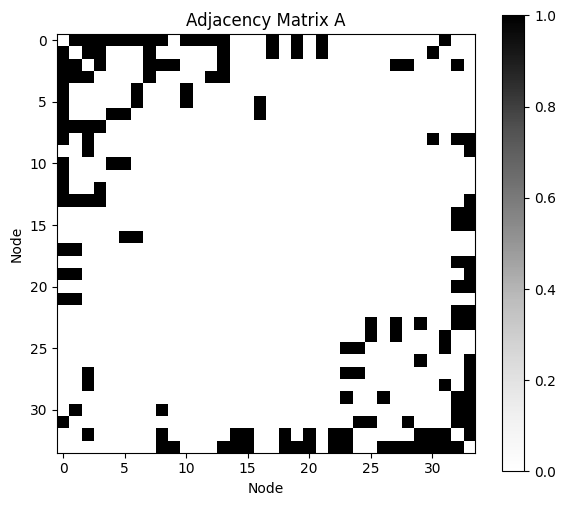

In [2]:
A = to_dense_adj(data.edge_index).squeeze(0).numpy()

print(f"Adjacency matrix shape: {A.shape}")
print(f"Symmetric: {np.allclose(A, A.T)}")
print(f"Non-zero entries: {int(A.sum())} (should be {data.num_edges})")

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(A, cmap="Greys", interpolation="none")
ax.set_title("Adjacency Matrix A")
ax.set_xlabel("Node")
ax.set_ylabel("Node")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## 3. Degree Distribution

Degree stats: min=1, max=17, mean=4.6, median=3.0

Top-5 most connected nodes:
  Node 33: degree 17, label 0
  Node 0: degree 16, label 1
  Node 32: degree 12, label 0
  Node 2: degree 10, label 1
  Node 1: degree 9, label 1


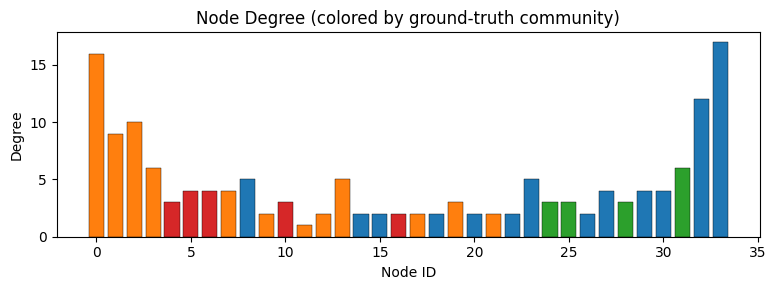

In [3]:
degrees = A.sum(axis=1).astype(int)
D = np.diag(degrees.astype(float))

print(f"Degree stats: min={degrees.min()}, max={degrees.max()}, mean={degrees.mean():.1f}, median={np.median(degrees):.1f}")
print(f"\nTop-5 most connected nodes:")
top5 = np.argsort(degrees)[::-1][:5]
for node in top5:
    print(f"  Node {node}: degree {degrees[node]}, label {data.y[node].item()}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(data.num_nodes), degrees, color=plt.cm.tab10(data.y.numpy()), edgecolor="k", linewidth=0.3)
ax.set_xlabel("Node ID")
ax.set_ylabel("Degree")
ax.set_title("Node Degree (colored by ground-truth community)")
plt.tight_layout()
plt.show()

## 4. Graph Visualization

Visualize the graph using spring layout, colored by ground-truth faction labels.

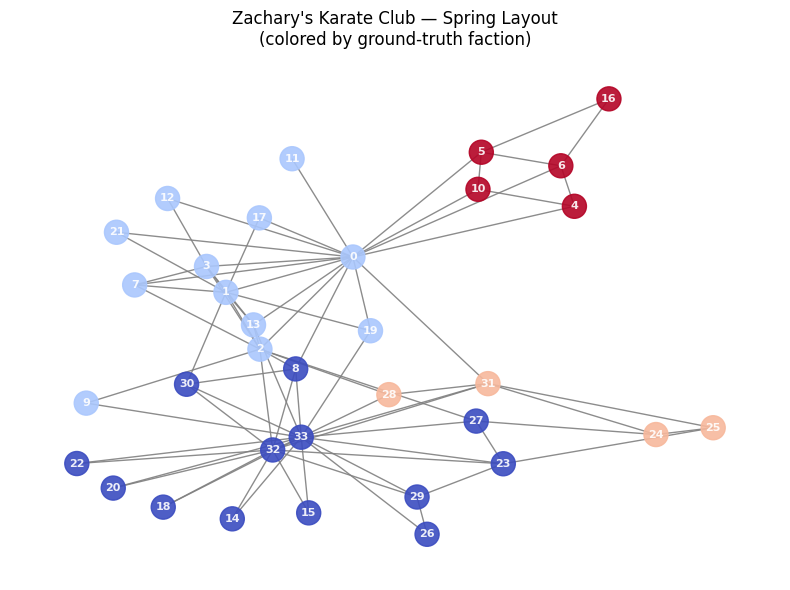

In [4]:
G = to_networkx(data, to_undirected=True)
labels = data.y.numpy()

pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx(
    G,
    pos=pos,
    node_color=labels,
    cmap="coolwarm",
    node_size=300,
    font_size=8,
    font_color="white",
    font_weight="bold",
    edge_color="gray",
    alpha=0.9,
    ax=ax,
)
ax.set_title("Zachary's Karate Club — Spring Layout\n(colored by ground-truth faction)")
ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Graph Laplacian and Spectrum

Compute the unnormalized and normalized Laplacians and inspect their eigenvalue spectra.

Key facts:
- The number of zero eigenvalues of $L$ equals the number of connected components.
- The **Fiedler value** ($\lambda_2$, smallest nonzero eigenvalue) measures algebraic connectivity.
- A spectral gap between $\lambda_2$ and $\lambda_3$ suggests the graph has two natural clusters.

Unnormalized Laplacian — first 6 eigenvalues: [-0.      0.4685  0.9092  1.125   1.2594  1.5993]
Normalized Laplacian   — first 6 eigenvalues: [-0.      0.1323  0.287   0.3873  0.6122  0.649 ]

Fiedler value (λ₂, unnorm): 0.4685
Spectral gap (λ₃ - λ₂):    0.4407


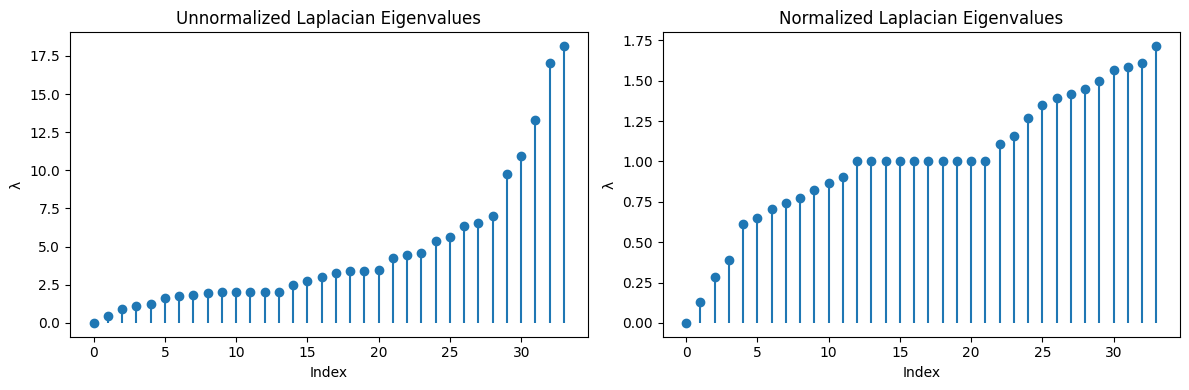

In [5]:
# Unnormalized Laplacian
L = D - A

# Normalized Laplacian: L_norm = I - D^{-1/2} A D^{-1/2}
inv_sqrt_deg = np.where(degrees > 0, 1.0 / np.sqrt(degrees.astype(float)), 0.0)
D_inv_sqrt = np.diag(inv_sqrt_deg)
L_norm = np.eye(data.num_nodes) - D_inv_sqrt @ A @ D_inv_sqrt

# Eigenvalues
eigvals_unnorm = np.linalg.eigvalsh(L)
eigvals_norm = np.linalg.eigvalsh(L_norm)

print(f"Unnormalized Laplacian — first 6 eigenvalues: {eigvals_unnorm[:6].round(4)}")
print(f"Normalized Laplacian   — first 6 eigenvalues: {eigvals_norm[:6].round(4)}")
print(f"\nFiedler value (λ₂, unnorm): {eigvals_unnorm[1]:.4f}")
print(f"Spectral gap (λ₃ - λ₂):    {eigvals_unnorm[2] - eigvals_unnorm[1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].stem(range(len(eigvals_unnorm)), eigvals_unnorm, markerfmt="o", basefmt=" ")
axes[0].set_title("Unnormalized Laplacian Eigenvalues")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("λ")

axes[1].stem(range(len(eigvals_norm)), eigvals_norm, markerfmt="o", basefmt=" ")
axes[1].set_title("Normalized Laplacian Eigenvalues")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("λ")

plt.tight_layout()
plt.show()

## 6. Fiedler Vector Preview

The eigenvector corresponding to $\lambda_2$ (the Fiedler vector) gives a 1-D embedding that often separates communities. This is a preview of what we'll explore fully in the Laplacian eigenmaps notebook.

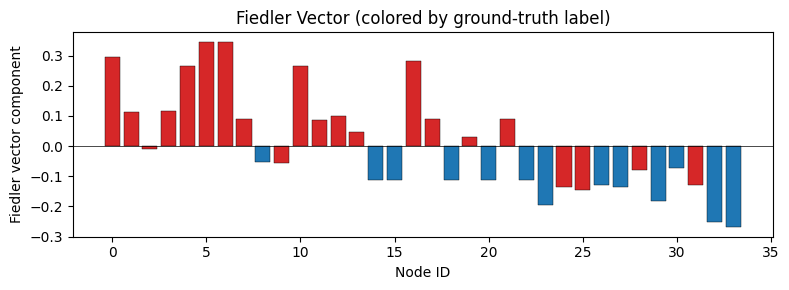

Fiedler sign → community accuracy: 67.6%


In [6]:
# Fiedler vector from normalized Laplacian
eigvals, eigvecs = np.linalg.eigh(L_norm)
fiedler = eigvecs[:, 1]  # eigenvector for λ₂

fig, ax = plt.subplots(figsize=(8, 3))
colors = ["tab:blue" if labels[i] == 0 else "tab:red" for i in range(data.num_nodes)]
ax.bar(range(data.num_nodes), fiedler, color=colors, edgecolor="k", linewidth=0.3)
ax.axhline(0, color="k", linewidth=0.5)
ax.set_xlabel("Node ID")
ax.set_ylabel("Fiedler vector component")
ax.set_title("Fiedler Vector (colored by ground-truth label)")
plt.tight_layout()
plt.show()

# Check how well sign of Fiedler vector predicts community
predicted = (fiedler > 0).astype(int)
acc1 = (predicted == labels).mean()
acc2 = ((1 - predicted) == labels).mean()
print(f"Fiedler sign → community accuracy: {max(acc1, acc2)*100:.1f}%")